Shape: (250, 4)
       Hardware_Capex  Data_Center_Power_MW  Cloud_GPU_Deployments  \
count       250.00000            250.000000             250.000000   
mean        417.81120             63.210360              50.434200   
std         223.08028             33.855198              27.010512   
min          53.80000             -5.640000               5.440000   
25%         223.18500             35.585000              25.512500   
50%         426.99500             63.390000              48.945000   
75%         614.96250             91.875000              74.225000   
max         790.17000            128.940000              99.050000   

       AI_Software_Revenue  
count           250.000000  
mean            950.498040  
std             406.249335  
min             196.480000  
25%             594.177500  
50%             925.640000  
75%            1265.307500  
max            1838.510000  

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results       

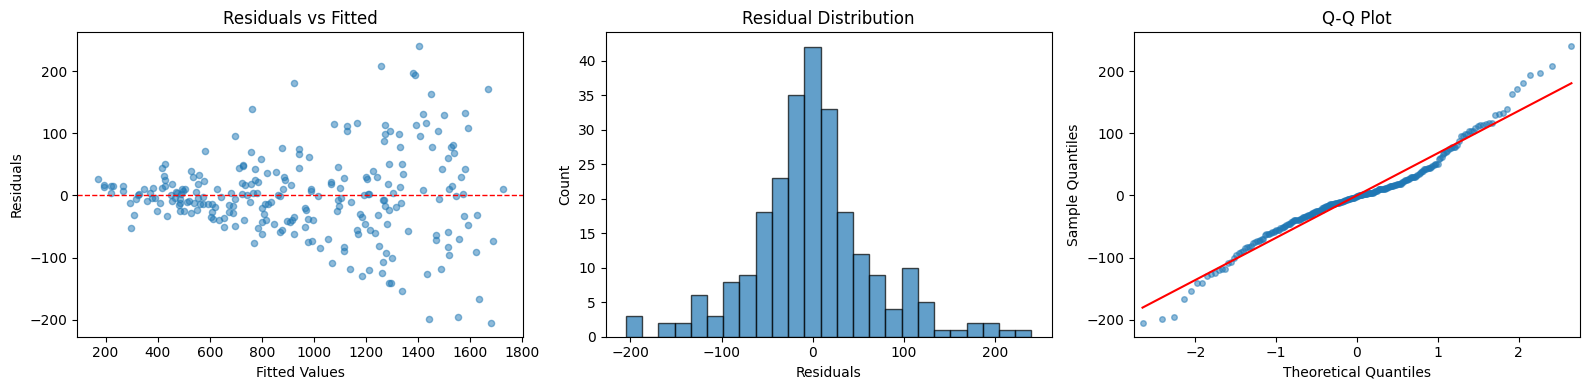


Plot saved to step1_diagnostics.png


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('Nvidia_AI_Capex_Diagnostics_2026.csv')
print("Shape:", df.shape)
print(df.describe())

# Naive baseline OLS
formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("\n--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

# VIF
X = df[['Hardware_Capex', 'Data_Center_Power_MW', 'Cloud_GPU_Deployments']]
X_const = sm.add_constant(X)
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X_const.values, i+1) for i in range(X.shape[1])]
})
print("\n--- VIF ---")
print(vif_data)

# Breusch-Pagan
bp_stat, bp_pval, _, _ = het_breuschpagan(baseline_model.resid, baseline_model.model.exog)
print(f"\n--- BREUSCH-PAGAN ---")
print(f"LM Statistic: {bp_stat:.4f}, p-value: {bp_pval:.6f}")

# Durbin-Watson
dw = durbin_watson(baseline_model.resid)
print(f"\n--- DURBIN-WATSON ---")
print(f"DW Statistic: {dw:.4f}")

# Correlation matrix
print("\n--- CORRELATION MATRIX ---")
print(df.corr().round(4))

# Diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs Fitted
axes[0].scatter(baseline_model.fittedvalues, baseline_model.resid, alpha=0.5, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Residual histogram
axes[1].hist(baseline_model.resid, bins=25, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# Q-Q plot
sm.qqplot(baseline_model.resid, line='s', ax=axes[2], alpha=0.5, markersize=4)
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('step1_diagnostics.png', dpi=150)
plt.show()
print("\nPlot saved to step1_diagnostics.png")

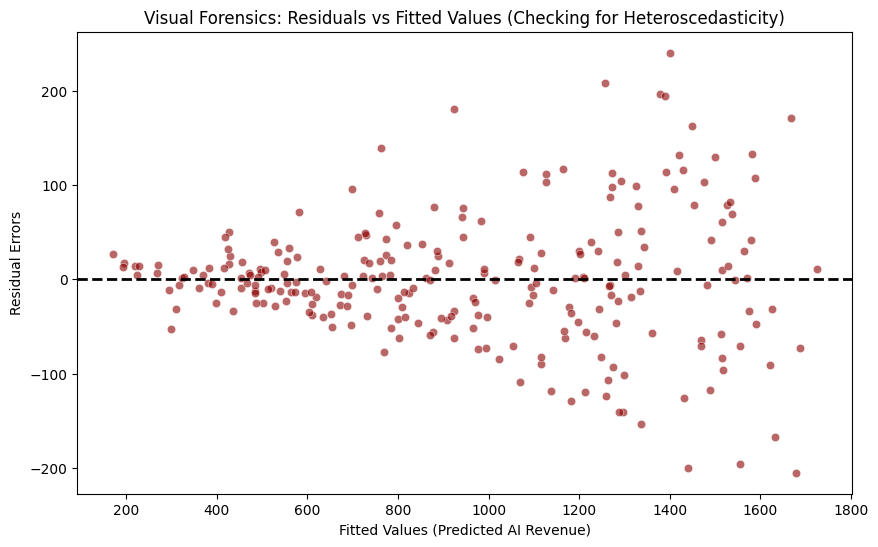

In [4]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [5]:
# Step 3: The White Test Execution
from statsmodels.stats.diagnostic import het_white

exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.4f}" for x in white_test_results])))


--- WHITE TEST RESULTS ---
{'LM Statistic': '57.2846', 'LM-Test p-value': '0.0000', 'F-Statistic': '7.9267', 'F-Test p-value': '0.0000'}


In [6]:
# Step 4: Variance Inflation Factor (VIF) Loop
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    col_name = baseline_model.model.exog_names[i]
    print(f"{col_name}: VIF = {vif:.4f}")


--- VARIANCE INFLATION FACTORS ---
Hardware_Capex: VIF = 18.1853
Data_Center_Power_MW: VIF = 18.1847
Cloud_GPU_Deployments: VIF = 1.0003


In [9]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())


--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2375.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          2.91e-181
Time:                         19:56:08   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [12]:
# ============================================================
# INTERACTIVE OLS DIAGNOSTIC DASHBOARD
# P.R.I.M.E. Expansion — Streamlit + Plotly
# Run with: streamlit run dashboard.py
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# ------------------------------------------------------------
# PAGE CONFIG
# st.set_page_config must be the first Streamlit call in the
# script — it sets the browser tab title and layout width.
# ------------------------------------------------------------
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ------------------------------------------------------------
# DATA LOADING & CACHING
# @st.cache_data tells Streamlit to cache the function's return
# value. On reruns (triggered by any widget interaction), the
# function is NOT re-executed — Streamlit serves the cached
# result instead. This prevents reloading the CSV every time
# the user clicks a toggle or moves a slider.
# ------------------------------------------------------------
@st.cache_data
def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

# ------------------------------------------------------------
# MODEL FITTING & CACHING
# @st.cache_resource is used for heavyweight objects like fitted
# models. Unlike cache_data (which hashes serializable objects),
# cache_resource stores the object in memory across sessions.
# The models are only fitted once, no matter how many times the
# dashboard rerenders.
# ------------------------------------------------------------
@st.cache_resource
def fit_models(csv_path: str):
    df = load_data(csv_path)
    formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'

    naive_model  = smf.ols(formula, data=df).fit()
    robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')

    # VIF — skip index 0 (intercept column)
    exog        = naive_model.model.exog
    exog_names  = naive_model.model.exog_names
    vif_df = pd.DataFrame({
        'Variable': exog_names[1:],
        'VIF':      [round(variance_inflation_factor(exog, i), 4)
                     for i in range(1, exog.shape[1])]
    })

    # White test
    white_stat, white_p, white_f, white_fp = het_white(naive_model.resid, exog)

    # Breusch-Pagan test
    bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(naive_model.resid, exog)

    # Durbin-Watson
    dw_stat = durbin_watson(naive_model.resid)

    diagnostics = {
        'White LM Stat':    round(white_stat, 4),
        'White p-value':    round(white_p, 6),
        'BP LM Stat':       round(bp_stat, 4),
        'BP p-value':       round(bp_p, 6),
        'Durbin-Watson':    round(dw_stat, 4),
    }

    return df, naive_model, robust_model, vif_df, diagnostics


# ------------------------------------------------------------
# SIDEBAR
# st.sidebar.* renders widgets in the collapsible left panel.
# Widgets return their current value every time the script
# reruns, so `csv_path` and `model_choice` are always fresh.
# ------------------------------------------------------------
st.sidebar.title("⚙️ Dashboard Controls")

csv_path = st.sidebar.text_input(
    "CSV file path",
    value="Nvidia_AI_Capex_Diagnostics_2026.csv",
    help="Relative or absolute path to your dataset."
)

model_choice = st.sidebar.radio(
    "Model summary to display",
    options=["Naive OLS", "Robust HC3"],
    index=0,
    help="Toggle between the uncorrected and HC3-corrected model summaries."
)

show_raw_data = st.sidebar.checkbox("Show raw data sample", value=False)

# ------------------------------------------------------------
# LOAD EVERYTHING
# Wrapped in try/except so a bad file path shows a clear error
# instead of a raw Python traceback.
# ------------------------------------------------------------
try:
    df, naive_model, robust_model, vif_df, diagnostics = fit_models(csv_path)
except FileNotFoundError:
    st.error(f"File not found: `{csv_path}`. Upload it to your working directory and refresh.")
    st.stop()   # Halts execution — nothing below this line renders.

# ------------------------------------------------------------
# MAIN LAYOUT
# st.columns([w1, w2]) splits the page into proportional
# columns. Content assigned to a column object renders side
# by side — no HTML/CSS required.
# ------------------------------------------------------------
st.title("OLS Regression Diagnostic Dashboard")
st.markdown("**Dataset:** Nvidia AI Capex · **Target:** `AI_Software_Revenue`")

if show_raw_data:
    st.subheader("Raw data sample")
    # st.dataframe renders a scrollable, sortable table.
    st.dataframe(df.head(20), use_container_width=True)

st.divider()  # Horizontal rule — purely cosmetic separator.

# ── Row 1: top-level fit metrics ────────────────────────────
st.subheader("Model fit at a glance")

# st.metric renders a large KPI card with an optional delta
# arrow. Delta sign is inferred automatically from the value.
col1, col2, col3, col4, col5 = st.columns(5)
col1.metric("R²",         f"{naive_model.rsquared:.4f}")
col2.metric("Adj. R²",    f"{naive_model.rsquared_adj:.4f}")
col3.metric("F-statistic",f"{naive_model.fvalue:.1f}")
col4.metric("AIC",        f"{naive_model.aic:.1f}")
col5.metric("Obs.",       f"{int(naive_model.nobs)}")

st.divider()

# ── Row 2: model summary toggle ─────────────────────────────
st.subheader(f"Coefficient table — {model_choice}")

# Select the active model based on the sidebar radio widget.
active_model = naive_model if model_choice == "Naive OLS" else robust_model

# Build a clean DataFrame from the summary table so we can
# render it with st.dataframe instead of a raw text block.
summary_df = pd.DataFrame({
    'Variable':  active_model.model.exog_names,
    'Coef':      active_model.params.round(4),
    'Std Err':   active_model.bse.round(4),
    't-stat':    active_model.tvalues.round(3),
    'P > |t|':   active_model.pvalues.round(6),
    'CI Lower':  active_model.conf_int()[0].round(4),
    'CI Upper':  active_model.conf_int()[1].round(4),
}).reset_index(drop=True)

# st.dataframe with use_container_width stretches the table
# to fill whatever column width is available.
st.dataframe(
    summary_df.style.applymap(
        lambda v: 'color: green' if isinstance(v, float) and v < 0.05 else '',
        subset=['P > |t|']
    ),
    use_container_width=True
)

if model_choice == "Naive OLS":
    st.info("⚠️ Naive OLS standard errors are invalid under heteroskedasticity — p-values above are unreliable.")
else:
    st.success("✅ HC3 sandwich estimator applied — standard errors are heteroskedasticity-consistent.")

st.divider()

# ── Row 3: residual plots ────────────────────────────────────
st.subheader("Visual forensics — residual diagnostics")

# Two Plotly charts side by side using st.columns.
left, right = st.columns(2)

with left:
    # Residuals vs Fitted — the primary heteroskedasticity visual.
    fig_resid = px.scatter(
        x=naive_model.fittedvalues,
        y=naive_model.resid,
        labels={'x': 'Fitted values', 'y': 'Residuals'},
        title='Residuals vs Fitted values',
        opacity=0.6,
        color_discrete_sequence=['darkred']
    )
    # Add the zero-reference line as a horizontal shape.
    fig_resid.add_hline(y=0, line_dash='dash', line_color='black', line_width=1.5)
    fig_resid.update_layout(height=400)
    # st.plotly_chart renders an interactive Plotly figure.
    # use_container_width makes it fill the column.
    st.plotly_chart(fig_resid, use_container_width=True)

with right:
    # Residual histogram — check for approximate normality.
    fig_hist = px.histogram(
        x=naive_model.resid,
        nbins=30,
        labels={'x': 'Residuals', 'y': 'Count'},
        title='Residual distribution',
        color_discrete_sequence=['steelblue']
    )
    fig_hist.update_layout(height=400)
    st.plotly_chart(fig_hist, use_container_width=True)

# Q-Q plot — full width below the two charts.
theoretical_q = np.sort(np.random.normal(0, 1, len(naive_model.resid)))
sample_q      = np.sort(naive_model.resid / naive_model.resid.std())

fig_qq = go.Figure()
fig_qq.add_trace(go.Scatter(
    x=theoretical_q, y=sample_q,
    mode='markers', marker=dict(color='steelblue', size=5, opacity=0.6),
    name='Residuals'
))
# Reference line: perfect normality = 45-degree diagonal.
fig_qq.add_trace(go.Scatter(
    x=[theoretical_q.min(), theoretical_q.max()],
    y=[theoretical_q.min(), theoretical_q.max()],
    mode='lines', line=dict(color='red', dash='dash', width=1.5),
    name='Normal reference'
))
fig_qq.update_layout(
    title='Q-Q plot (standardised residuals vs theoretical normal)',
    xaxis_title='Theoretical quantiles',
    yaxis_title='Sample quantiles',
    height=380
)
st.plotly_chart(fig_qq, use_container_width=True)

st.divider()

# ── Row 4: VIF scores ────────────────────────────────────────
st.subheader("Multicollinearity — Variance Inflation Factors")

vif_left, vif_right = st.columns([1, 2])

with vif_left:
    # Colour-code the VIF column: green < 5, amber 5-10, red > 10.
    def colour_vif(val):
        if val < 5:   return 'color: green'
        if val < 10:  return 'color: orange'
        return 'color: red; font-weight: bold'

    st.dataframe(
        vif_df.style.applymap(colour_vif, subset=['VIF']),
        use_container_width=True
    )

with vif_right:
    fig_vif = px.bar(
        vif_df, x='Variable', y='VIF',
        title='VIF per predictor',
        color='VIF',
        color_continuous_scale=['green', 'orange', 'red'],
        text='VIF'
    )
    # Draw threshold lines so the severity bands are visible.
    fig_vif.add_hline(y=5,  line_dash='dot',  line_color='orange',
                      annotation_text='Moderate (5)', annotation_position='right')
    fig_vif.add_hline(y=10, line_dash='dash', line_color='red',
                      annotation_text='Severe (10)',  annotation_position='right')
    fig_vif.update_traces(texttemplate='%{text:.2f}', textposition='outside')
    fig_vif.update_layout(height=380, coloraxis_showscale=False)
    st.plotly_chart(fig_vif, use_container_width=True)

st.divider()

# ── Row 5: formal test results ───────────────────────────────
st.subheader("Formal diagnostic test results")

d_col1, d_col2, d_col3, d_col4, d_col5 = st.columns(5)
d_col1.metric("White LM stat",  diagnostics['White LM Stat'])
d_col2.metric("White p-value",  diagnostics['White p-value'],
              delta="Heteroskedastic" if diagnostics['White p-value'] < 0.05 else "OK",
              delta_color="inverse")
d_col3.metric("BP LM stat",     diagnostics['BP LM Stat'])
d_col4.metric("BP p-value",     diagnostics['BP p-value'],
              delta="Heteroskedastic" if diagnostics['BP p-value'] < 0.05 else "OK",
              delta_color="inverse")
d_col5.metric("Durbin-Watson",  diagnostics['Durbin-Watson'],
              delta="Borderline" if abs(diagnostics['Durbin-Watson'] - 2) > 0.3 else "OK",
              delta_color="inverse")

st.divider()
st.caption("Lab expansion · P.R.I.M.E. Framework · Built with Streamlit + Plotly + statsmodels")

2026-03-23 19:58:58.966 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 19:58:58.967 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-23 19:58:58.970 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 19:58:59.163 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-23 19:58:59.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 19:58:59.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 19:58:59.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runnin

DeltaGenerator()

In [11]:
!pip install streamlit plotly pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 115.2 MB/s eta 0:00:00
